In [4]:
!pip install xlrd==2.0.1

# Iniciando as bibliotecas

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
plt.style.use('dark_background')

### Ajusta o tamanho das imagens

In [6]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize']=15,6

# Leitura dos dataframes iniciais

In [7]:
data = "dadosIniciais.xlsx"
# Ler o arquivo Excel
data = pd.read_excel(data)

# Verifica como está o dataset

In [8]:
# Mostrar as primeiras linhas
print(data.head())

    1.137157   -0.061341    26.208588  -1.858761 
0    1.137499    0.082685   26.244322    1.471061
1    1.117805    0.225745   25.818823    4.754794
2    1.078412    0.365120   24.978243    8.000349
3    1.020086    0.498130   23.716368   11.057279
4    0.944010    0.622210   22.005617   13.972568


In [9]:
print(data.head())

    1.137157   -0.061341    26.208588  -1.858761 
0    1.137499    0.082685   26.244322    1.471061
1    1.117805    0.225745   25.818823    4.754794
2    1.078412    0.365120   24.978243    8.000349
3    1.020086    0.498130   23.716368   11.057279
4    0.944010    0.622210   22.005617   13.972568


In [10]:
df_input = pd.DataFrame()
df_input["Xreal"] = data.iloc[:, 0]
df_input["Ximg"] = data.iloc[:, 1]
df_input.head()

,Xreal,Ximg
0,1.137499,0.082685
1,1.117805,0.225745
2,1.078412,0.365120
3,1.020086,0.498130
4,0.944010,0.622210


In [11]:
#scaler = StandardScaler()
#colunas_para_normalizar = ['Xreal', 'Ximg']
# 4. Ajuste o scaler aos seus dados e transforme-os
#df_input = scaler.fit_transform(df_input[colunas_para_normalizar])
#df_input = pd.DataFrame(df_input, columns=['Xreal', 'Ximg'])

In [12]:
df_input.head()

,Xreal,Ximg
0,1.137499,0.082685
1,1.117805,0.225745
2,1.078412,0.365120
3,1.020086,0.498130
4,0.944010,0.622210


In [13]:
df_output = pd.DataFrame()
df_output["Yreal"] = data.iloc[:, 2]
df_output["Yimg"] = data.iloc[:, 3]
df_output.head()

,Yreal,Yimg
0,26.244322,1.471061
1,25.818823,4.754794
2,24.978243,8.000349
3,23.716368,11.057279
4,22.005617,13.972568


In [14]:
df_concat = pd.concat([df_input, df_output], axis=1)
df_concat.head()

,Xreal,Ximg,Yreal,Yimg
0,1.137499,0.082685,26.244322,1.471061
1,1.117805,0.225745,25.818823,4.754794
2,1.078412,0.365120,24.978243,8.000349
3,1.020086,0.498130,23.716368,11.057279
4,0.944010,0.622210,22.005617,13.972568


In [15]:
df_concat

,Xreal,Ximg,Yreal,Yimg
0,1.137499,0.082685,26.244322,1.471061
1,1.117805,0.225745,25.818823,4.754794
2,1.078412,0.365120,24.978243,8.000349
3,1.020086,0.498130,23.716368,11.057279
4,0.944010,0.622210,22.005617,13.972568
...,...,...,...,...
48378,0.852823,-0.726484,19.257505,-17.156517
48379,0.943207,-0.614669,21.376001,-14.639256
48380,1.018323,-0.492173,23.199469,-11.852586
48381,1.076463,-0.360888,24.612610,-8.843221


### Gráfico básico para ser verificado Y x X

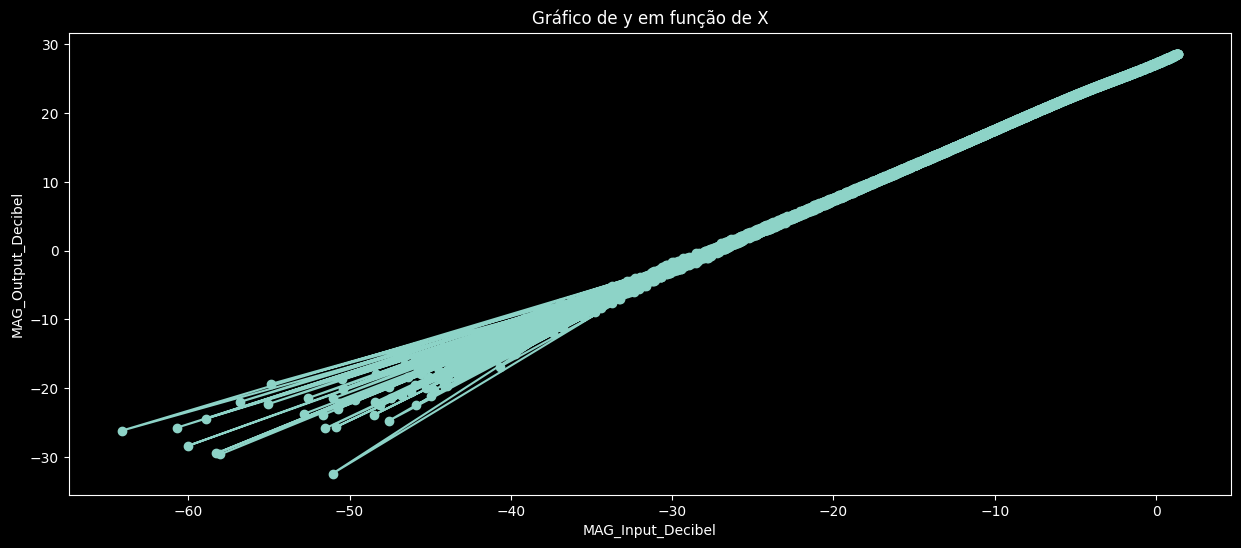

In [16]:
df_mag = pd.DataFrame()
df_mag["MAG_Input"] = np.sqrt(df_concat["Xreal"]**2 + df_concat["Ximg"]**2)
df_mag["MAG_Output"] = np.sqrt(df_concat["Yreal"]**2 + df_concat["Yimg"]**2)

df_mag["MAG_Input_Decibel"]= 20 * np.log10(df_mag["MAG_Input"])
df_mag["MAG_Output_Decibel"]= 20 * np.log10(df_mag["MAG_Output"])

df_mag["MAG_Input_Decibel"]= df_mag["MAG_Input_Decibel"]
df_mag["MAG_Output_Decibel"]= df_mag["MAG_Output_Decibel"]

plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel"], marker='o')
plt.xlabel('MAG_Input_Decibel')
plt.ylabel('MAG_Output_Decibel')
plt.title('Gráfico de y em função de X')
plt.show()

In [17]:
df_concat.shape

(48383, 4)

### Analisar a saida como uma série temporal

In [18]:
df_mag_y = pd.Series(df_mag['MAG_Output_Decibel'].values)

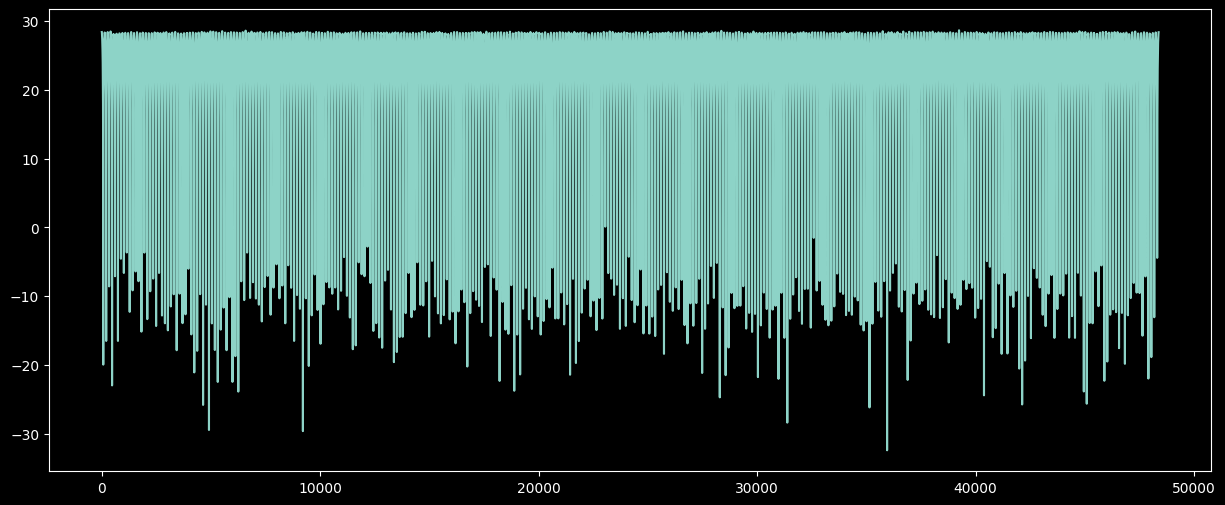

In [19]:
df_mag_y.plot()
plt.show()

In [20]:
df_mag_x = pd.Series(df_mag['MAG_Input_Decibel'].values)

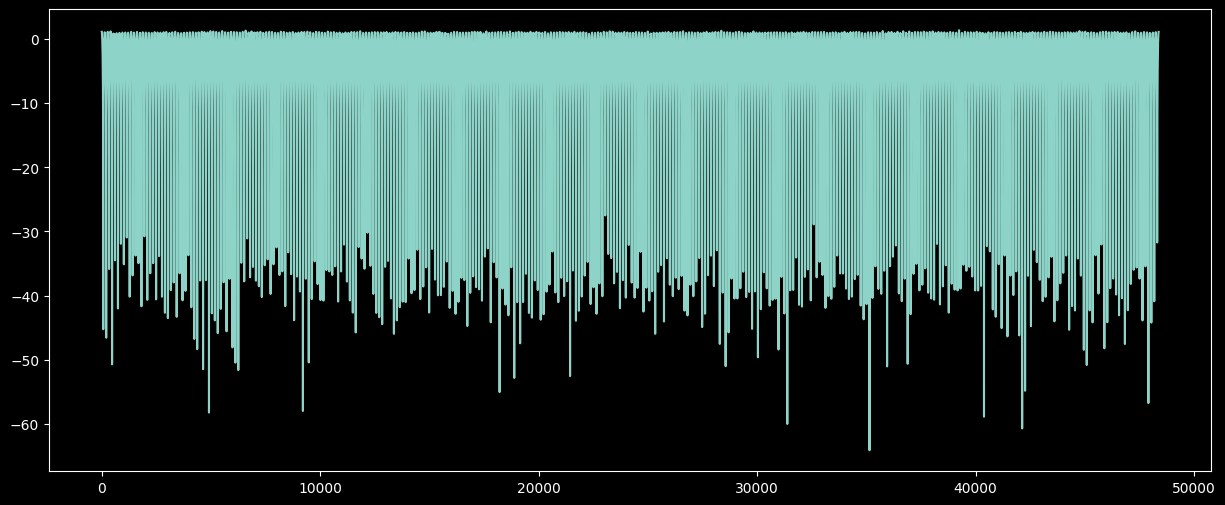

In [21]:
df_mag_x.plot()
plt.show()

### Gerando um histograma da série

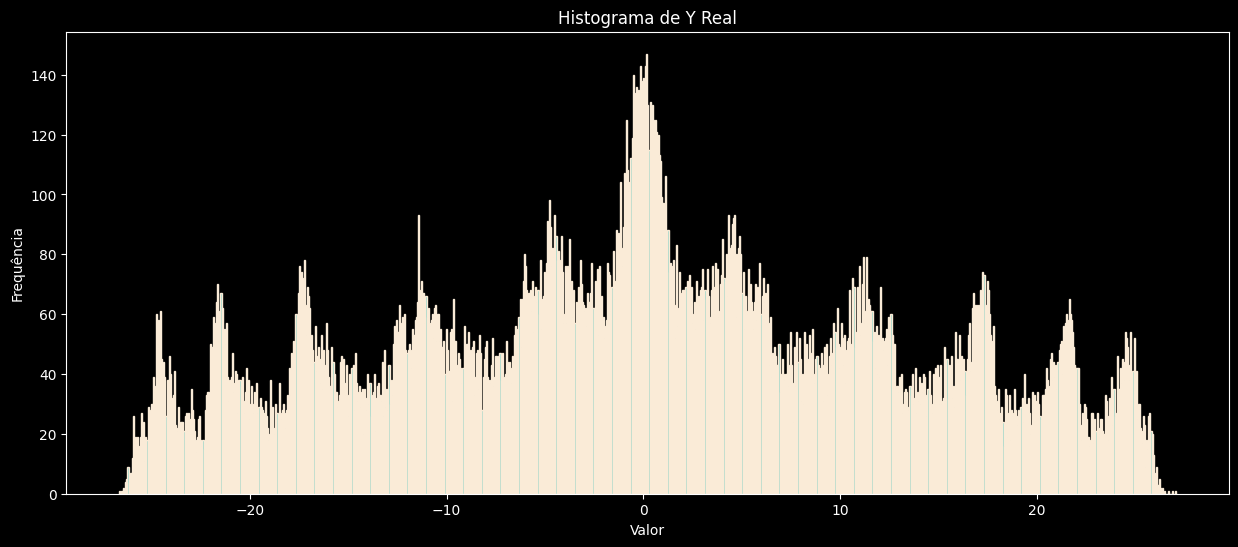

In [22]:
# Gerar histograma
plt.hist(df_output["Yreal"], bins=1000, edgecolor='antiquewhite')  # 'bins' define o número de intervalos
plt.title('Histograma de Y Real')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show()

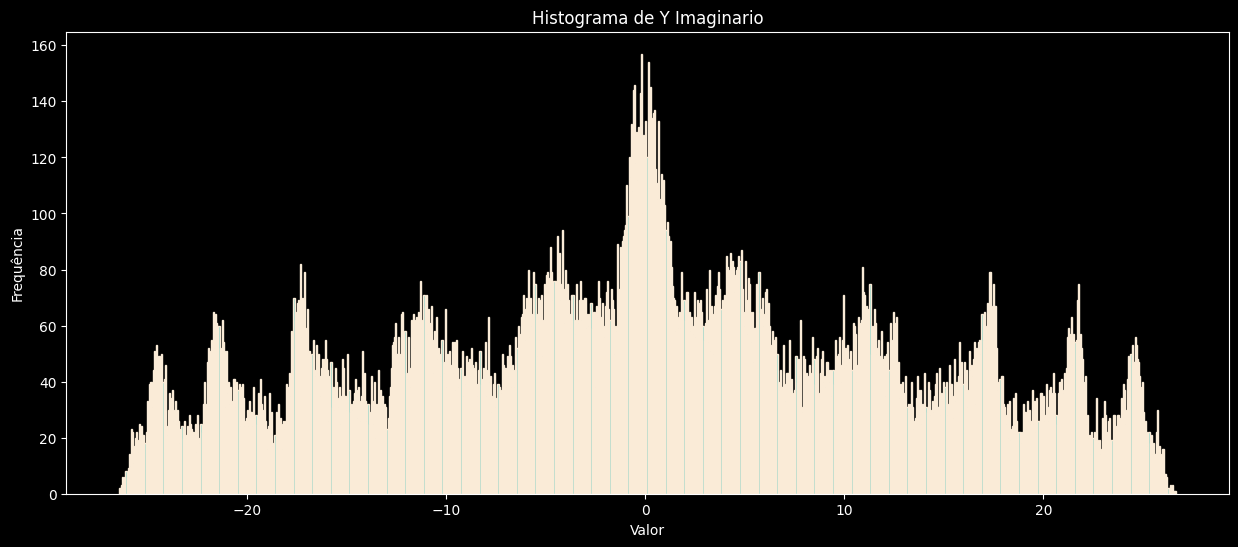

In [23]:
# Gerar histograma
plt.hist(df_output["Yimg"], bins=1000, edgecolor='antiquewhite')  # 'bins' define o número de intervalos
plt.title('Histograma de Y Imaginario')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show()

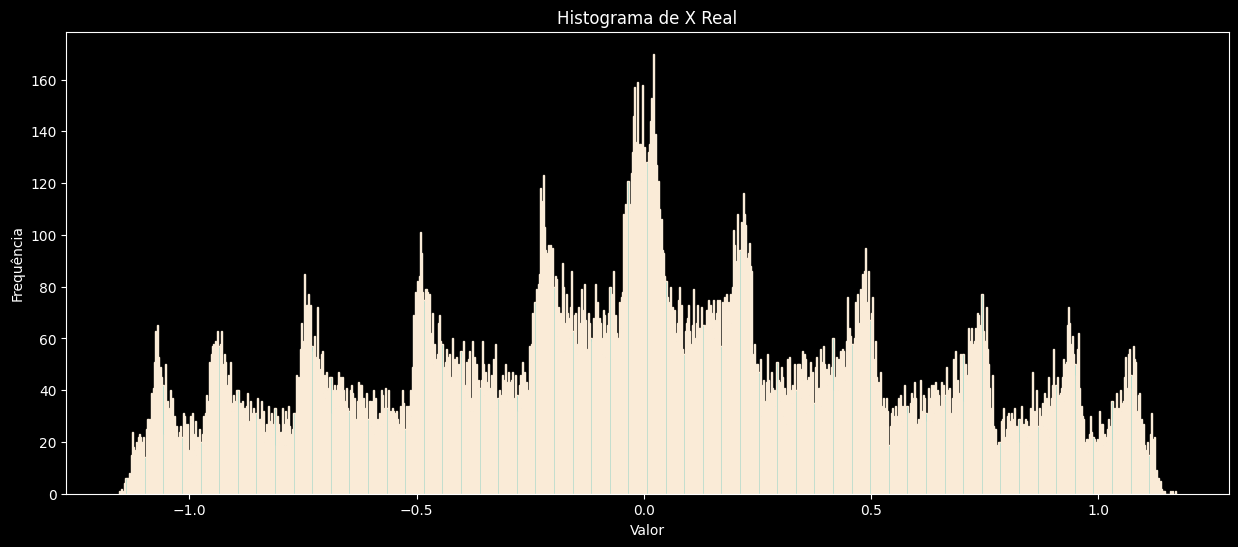

In [24]:
# Gerar histograma
plt.hist(df_input["Xreal"], bins=1000, edgecolor='antiquewhite')  # 'bins' define o número de intervalos
plt.title('Histograma de X Real')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show()

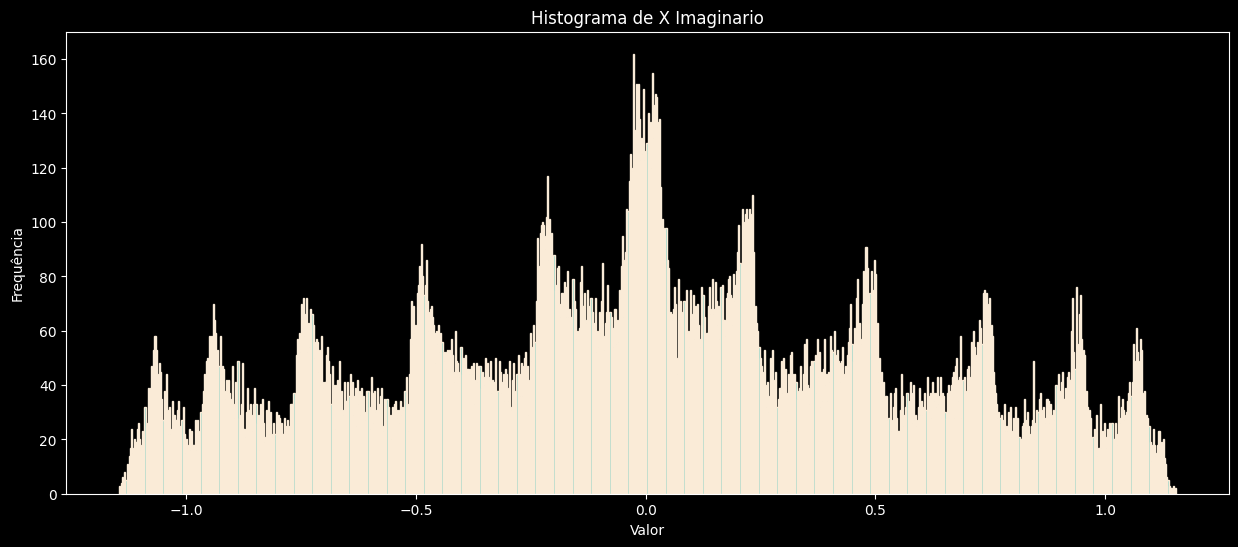

In [25]:
# Gerar histograma
plt.hist(df_input["Ximg"], bins=1000, edgecolor='antiquewhite')  # 'bins' define o número de intervalos
plt.title('Histograma de X Imaginario')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show()

### Teste de shapiro para verificar a distribuição
### Hipótese nula (H0): os dados seguem uma distribuição normal.
### Hipótese alternativa (H1): os dados não seguem uma distribuição normal.
### p > alpha: Falha em rejeitar H0: os dados parecem normais
### p <= alpha: os dados não parecem normais

In [26]:
from scipy.stats import shapiro
def calcula_shapiro_teste(serie):
    stat, p = shapiro(serie)
    print('Estatística de teste Yreal =', stat)
    print('p-valor Yreal=', p)
    alpha = 0.05
    if p > alpha:
        print("Falha em rejeitar H0: os dados parecem normais")
    else:
        print("Rejeita H0: os dados não parecem normais")

### Normalidade y real e imaginario

In [27]:
calcula_shapiro_teste(df_output["Yreal"])
calcula_shapiro_teste(df_output["Yimg"])

Estatística de teste Yreal = 0.9806814866718211
p-valor Yreal= 1.7180237190579475e-59
Rejeita H0: os dados não parecem normais
Estatística de teste Yreal = 0.980662526086569
p-valor Yreal= 1.6436006255628414e-59
Rejeita H0: os dados não parecem normais


### Normalidade x real e imaginario

In [28]:
calcula_shapiro_teste(df_input["Xreal"])
calcula_shapiro_teste(df_input["Ximg"])

Estatística de teste Yreal = 0.9814574044840102
p-valor Yreal= 1.0860890534575395e-58
Rejeita H0: os dados não parecem normais
Estatística de teste Yreal = 0.9814417381824334
p-valor Yreal= 1.0457391016283386e-58
Rejeita H0: os dados não parecem normais


# Vamos fazer testes de estacionalidade

In [29]:
import statsmodels.tsa.stattools

### Teste KPSS
### Ha = Não é estacionária: estatística do teste > valor crítico
### H0 = é estacionária: estatística do teste <= valor crítico

In [30]:
def kpss_teste(serie):
    kpss_seriey = statsmodels.tsa.stattools.kpss(df_output["Yreal"])
    print("Estatística do teste: ", kpss_seriey[0])
    print("p_value do teste: ", kpss_seriey[1])
    print("Número de lags: ", kpss_seriey[2])
    print("Valores Críticos: ")
    for chave, valor in kpss_seriey[3].items():
        print(chave, valor)

### Para o Yreal e IMG

In [31]:
kpss_teste(df_output["Yreal"])
kpss_teste(df_output["Yimg"])

Estatística do teste:  0.001684773036058327
p_value do teste:  0.1
Número de lags:  109
Valores Críticos: 
10% 0.347
5% 0.463
2.5% 0.574
1% 0.739
Estatística do teste:  0.001684773036058327
p_value do teste:  0.1
Número de lags:  109
Valores Críticos: 
10% 0.347
5% 0.463
2.5% 0.574
1% 0.739


C:\Users\zaack\AppData\Local\Temp\ipykernel_16060\6171303.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_seriey = statsmodels.tsa.stattools.kpss(df_output["Yreal"])
C:\Users\zaack\AppData\Local\Temp\ipykernel_16060\6171303.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_seriey = statsmodels.tsa.stattools.kpss(df_output["Yreal"])


### Teste de DF (Dickey Fuller)
### H0 = não é estacionária: estatística do teste > valor crítico
### Ha = é estacionária: estatística do teste <=valor crítico

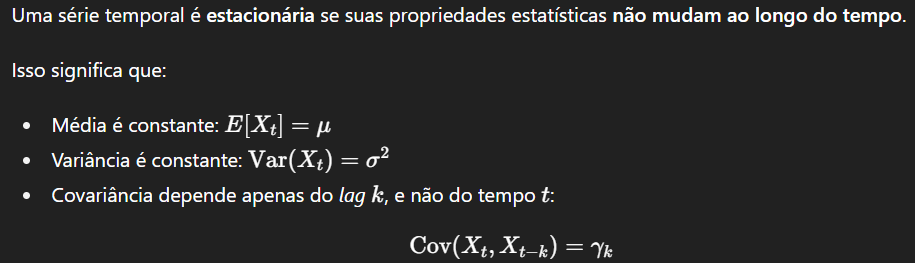

In [32]:
def dickey_fuller_test(serie):
    df_seriey = statsmodels.tsa.stattools.adfuller(serie)
    print("Estatística do teste: ", df_seriey[0])
    print("p_value do teste: ", df_seriey[1])
    print("Valores Críticos: ")
    for chave, valor in df_seriey[4].items():
        print(chave, valor)

### Teste DF Y (real e Img)

In [33]:
dickey_fuller_test(df_output["Yreal"])
dickey_fuller_test(df_output["Yimg"])

Estatística do teste:  -25.270371065823074
p_value do teste:  0.0
Valores Críticos: 
1% -3.4304853263815924
5% -2.8615998114357426
10% -2.5668018356570568
Estatística do teste:  -25.445905497749894
p_value do teste:  0.0
Valores Críticos: 
1% -3.4304853263815924
5% -2.8615998114357426
10% -2.5668018356570568


### Teste DF X (real e Img)

In [34]:
dickey_fuller_test(df_input["Xreal"])
dickey_fuller_test(df_input["Ximg"])

Estatística do teste:  -15.092443978065791
p_value do teste:  8.156561597637556e-28
Valores Críticos: 
1% -3.4304853263815924
5% -2.8615998114357426
10% -2.5668018356570568
Estatística do teste:  -15.24975420358423
p_value do teste:  5.028377878457752e-28
Valores Críticos: 
1% -3.4304853263815924
5% -2.8615998114357426
10% -2.5668018356570568


In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Verificando a Autocorrelação na serieY

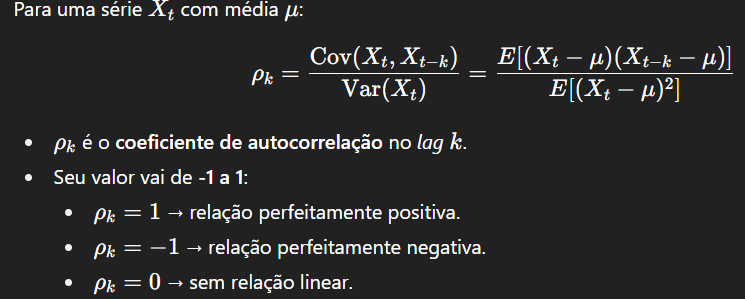

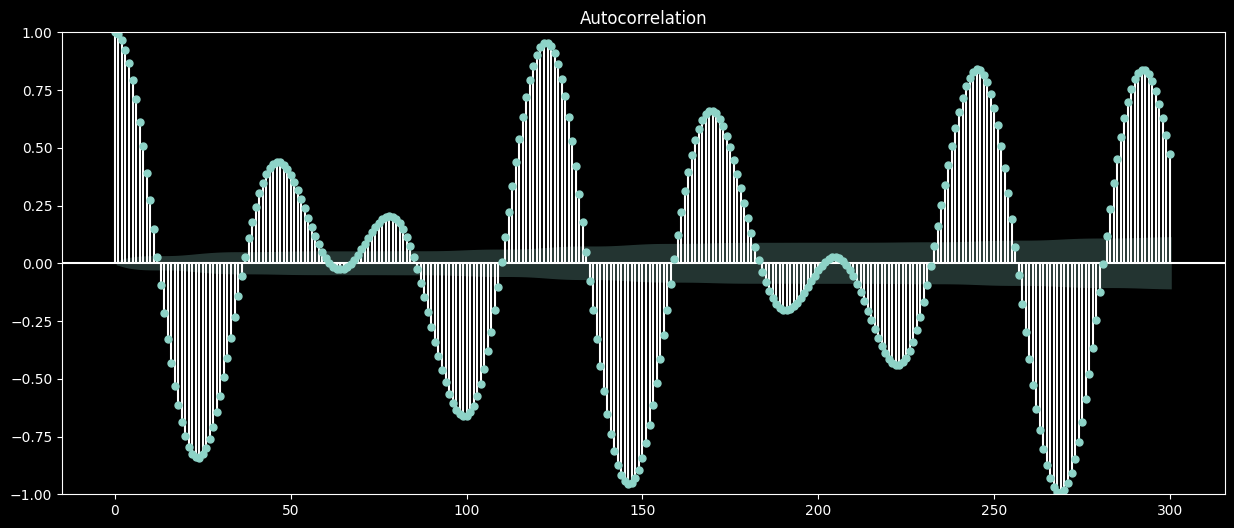

In [36]:
plot_acf(df_output["Yreal"], lags=300)
plt.show()

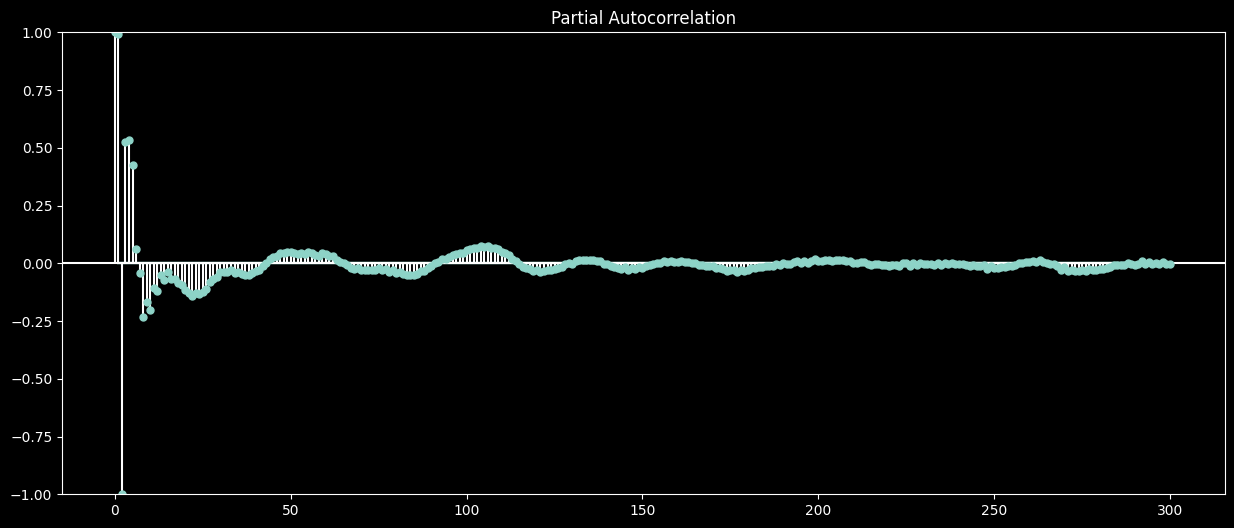

In [37]:
plot_pacf(df_output["Yimg"], lags=300)
plt.show()

### Verificando a Autocorrelação na serieX

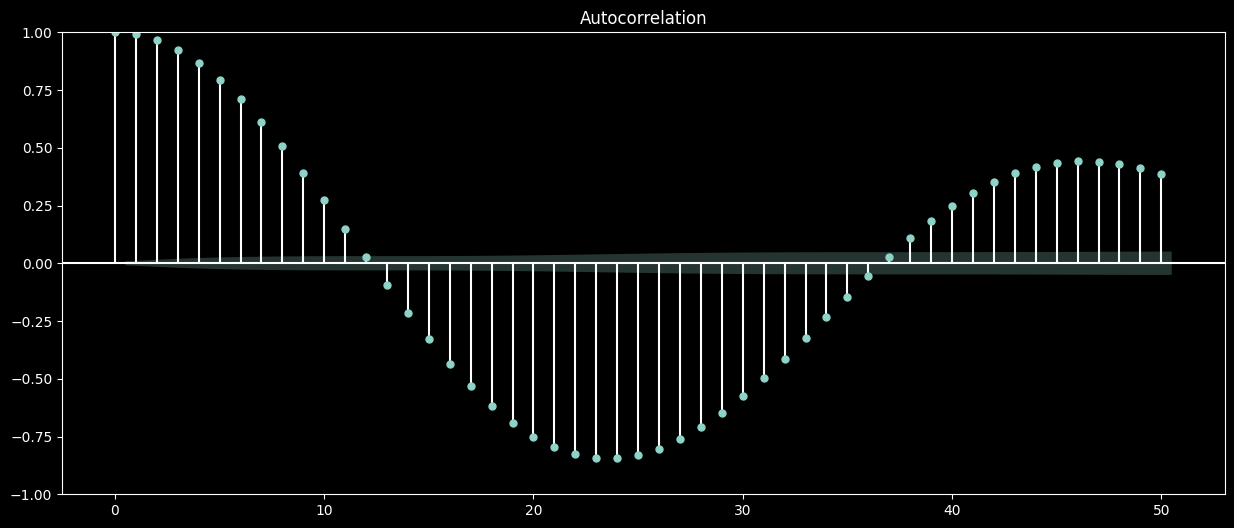

In [38]:
plot_acf(df_input["Xreal"], lags=50)
plt.show()

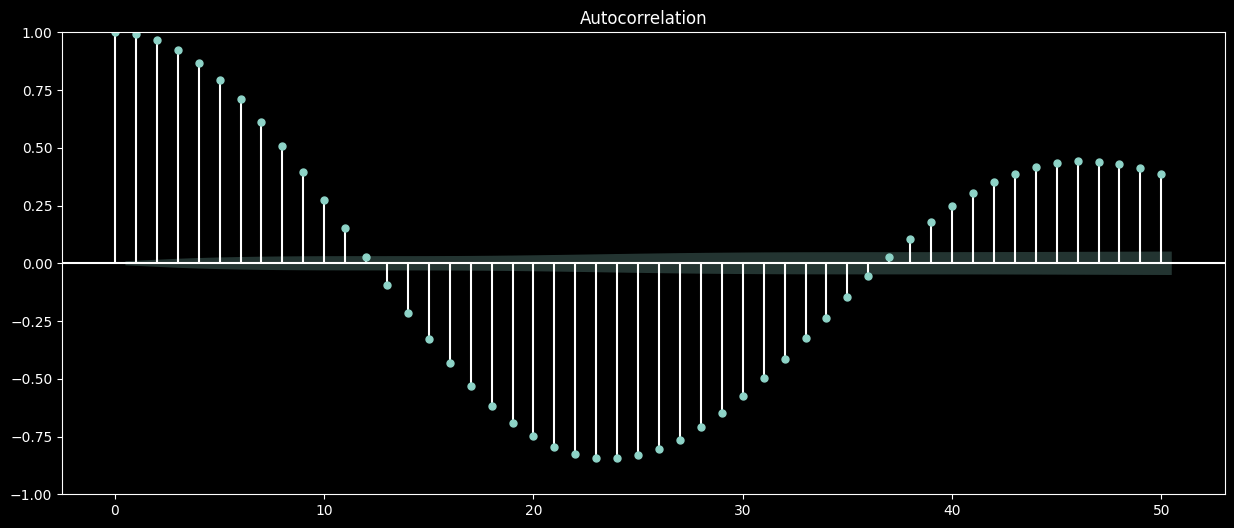

In [39]:
plot_acf(df_input["Ximg"], lags=50)
plt.show()

In [40]:
df_concat.shape

(48383, 4)

## Implementação de um modelo com base em Vetor AutoRegressivo de Média Móvel com Regressores Exógenos

### Vetor AutoRegressivo (VAR): Cada variável na sua série temporal é modelada como uma função linear dos seus próprios valores passados e dos valores passados de todas as outras variáveis do sistema.

### Média Móvel (VMA): Incorpora a dependência entre uma série temporal e erros de previsão passados (os choques ou inovações).

### Exógeno (X): Permite incluir variáveis externas (regressores exógenos) que influenciam as variáveis internas do modelo, mas que não são influenciadas por elas.

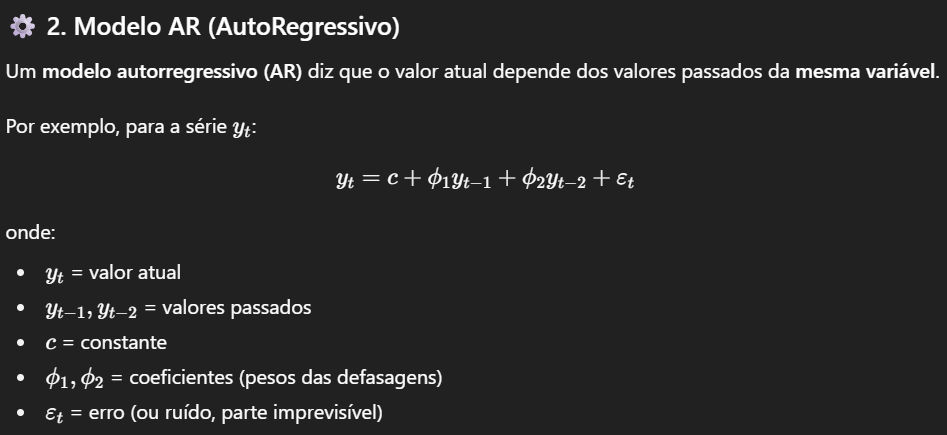

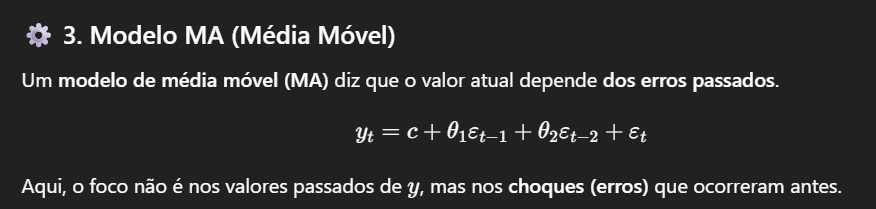

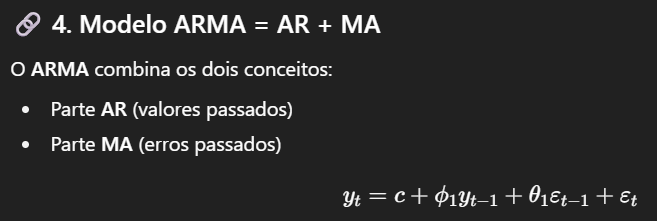

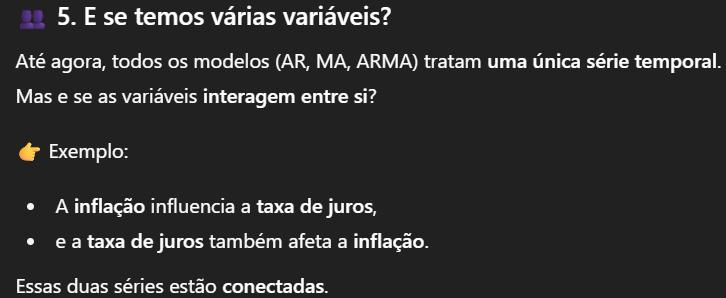

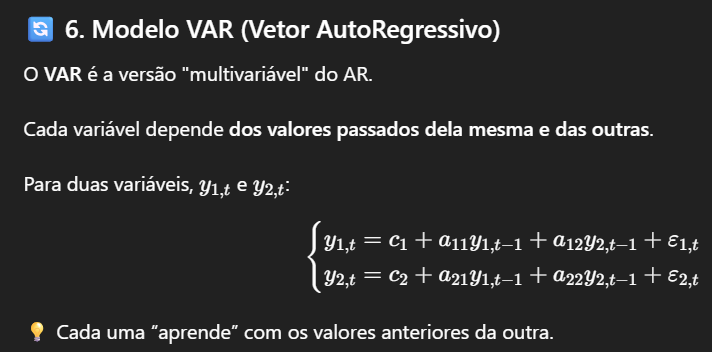

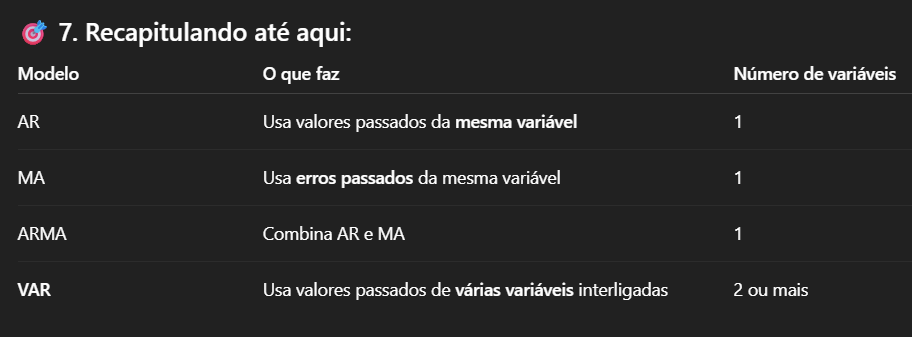

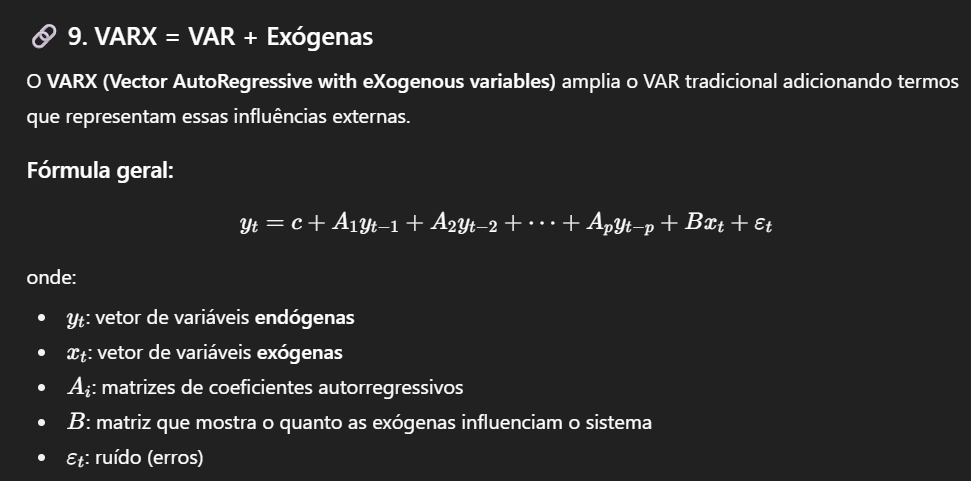

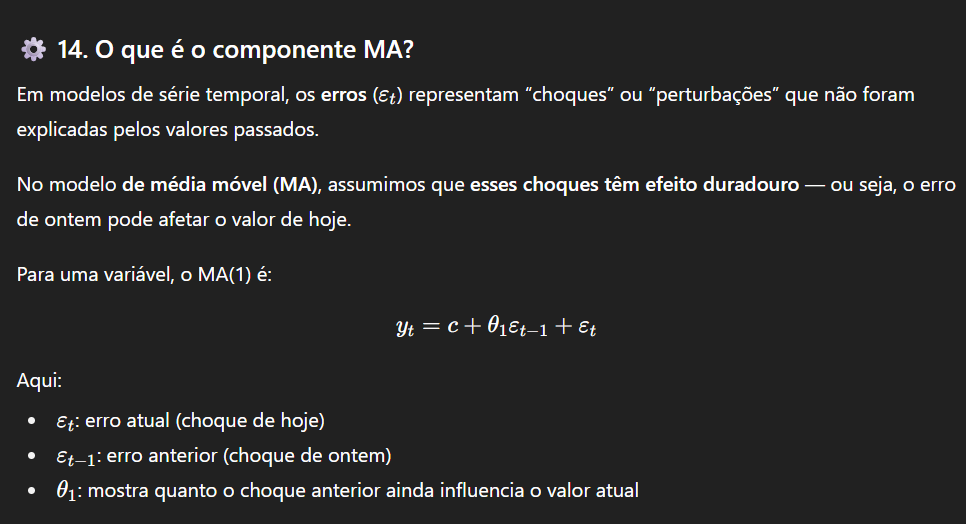

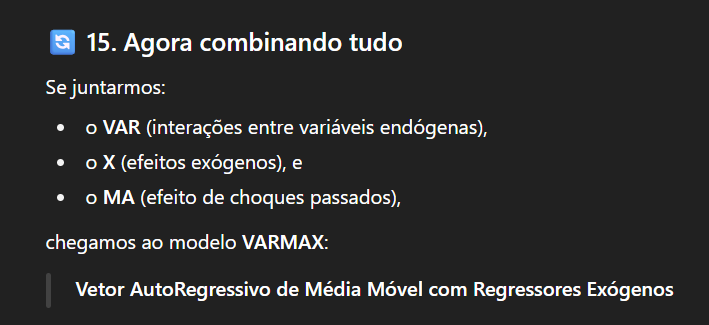

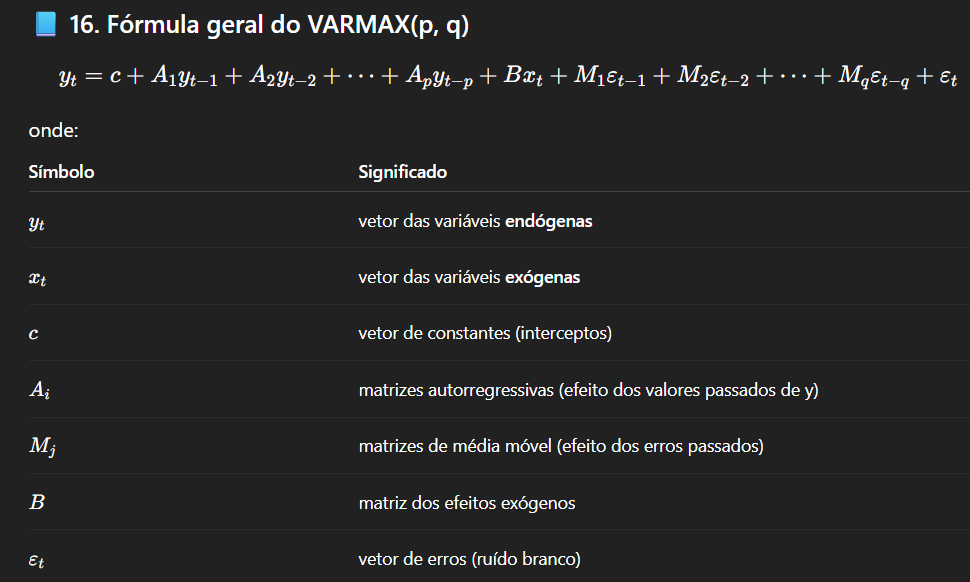

Modelo geral com xt-m influenciando:

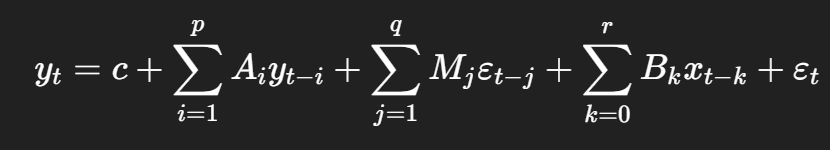
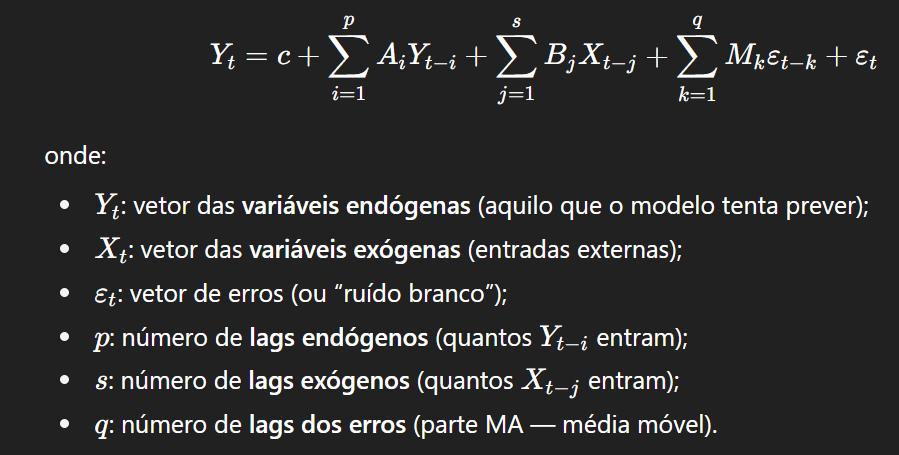

Como são escolhidos os valores dos coeficientes?

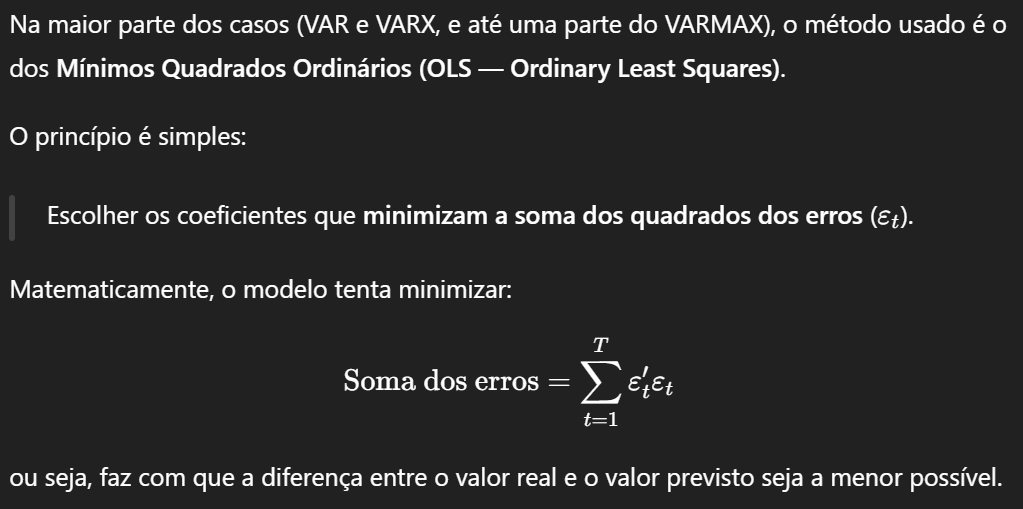

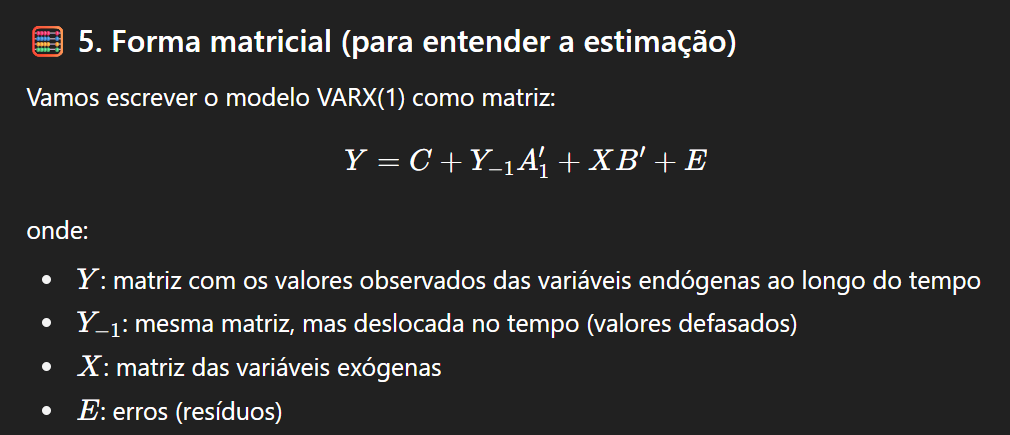

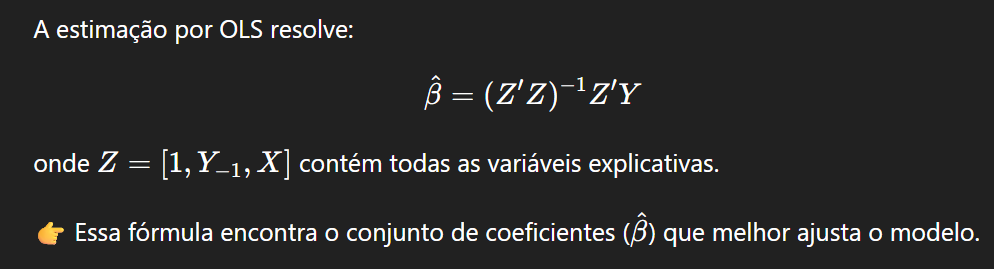

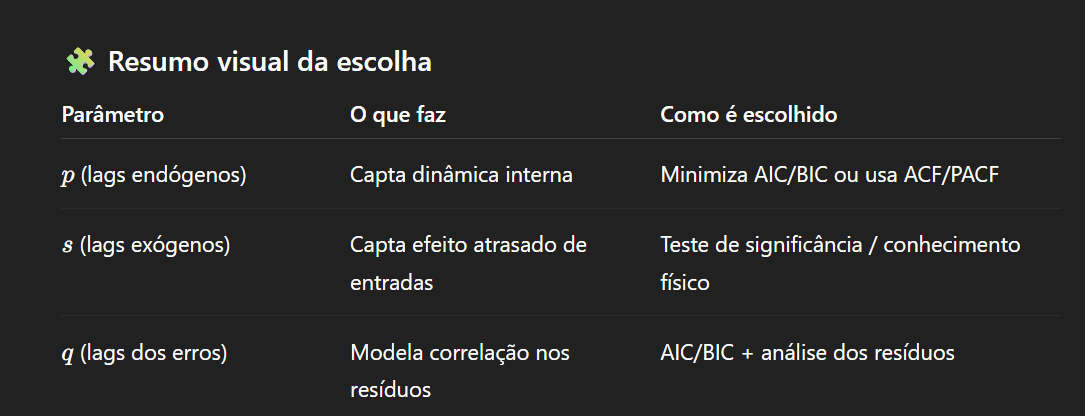

In [41]:
from statsmodels.tsa.api import VARMAX
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

### Divisão dos dados em treino, validação (encontro do melhor número de lags) e teste

In [42]:
train_frac=0.6
val_frac=0.2

n = len(df_concat)


train_end = int(n * train_frac)
val_end = int(n * (train_frac + val_frac))

train = df_concat.iloc[:train_end]
val = df_concat.iloc[train_end:val_end]
test = df_concat.iloc[val_end:]



In [43]:
train.head()

,Xreal,Ximg,Yreal,Yimg
0,1.137499,0.082685,26.244322,1.471061
1,1.117805,0.225745,25.818823,4.754794
2,1.078412,0.365120,24.978243,8.000349
3,1.020086,0.498130,23.716368,11.057279
4,0.944010,0.622210,22.005617,13.972568


In [44]:
train.tail()

,Xreal,Ximg,Yreal,Yimg
29024,0.817134,-0.780057,18.503824,-18.309040
29025,0.913069,-0.671584,20.775902,-15.866060
29026,0.993183,-0.549854,22.687193,-13.052302
29027,1.055763,-0.417002,24.145628,-10.024156
29028,1.099490,-0.275571,25.196806,-6.811991


In [45]:
train.shape

(29029, 4)

In [46]:
val.head()

,Xreal,Ximg,Yreal,Yimg
29029,1.123545,-0.128402,25.823204,-3.415201
29030,1.127553,0.021431,25.948101,0.011700
29031,1.111608,0.170736,25.637697,3.450372
29032,1.076238,0.316324,24.935619,6.751529
29033,1.022374,0.455127,23.751780,9.966703


In [47]:
val.tail()

,Xreal,Ximg,Yreal,Yimg
38701,0.850646,-0.726763,19.160643,-17.200718
38702,0.936397,-0.614338,21.196011,-14.681006
38703,1.006598,-0.491479,22.885666,-11.864506
38704,1.060221,-0.360276,24.222952,-8.889906
38705,1.096502,-0.222941,25.105867,-5.725583


In [48]:
val.shape

(9677, 4)

In [49]:
test.head()

,Xreal,Ximg,Yreal,Yimg
38706,1.114922,-0.081778,25.591318,-2.478422
38707,1.115212,0.060836,25.698118,0.774433
38708,1.097355,0.202482,25.368166,4.032464
38709,1.061576,0.340715,24.606976,7.238338
38710,1.008408,0.473100,23.453981,10.300141


In [50]:
test.tail()

,Xreal,Ximg,Yreal,Yimg
48378,0.852823,-0.726484,19.257505,-17.156517
48379,0.943207,-0.614669,21.376001,-14.639256
48380,1.018323,-0.492173,23.199469,-11.852586
48381,1.076463,-0.360888,24.612610,-8.843221
48382,1.116198,-0.222894,25.594149,-5.662292


In [51]:
test.shape

(9677, 4)

### Função que roda faz um "gridsearch"para escolher o melhor número de lags

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VARMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------
# Função de seleção de lag (m)
# ------------------------
def select_lag_varx(train, val, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg'), max_lag=3, verbose=True):

    endog_train = train[list(endog_cols)]
    exog_train = train[list(exog_cols)]
    endog_val = val[list(endog_cols)]
    exog_val = val[list(exog_cols)]

    results = []

    for p in range(1, max_lag+1):
        try:
            model = VARMAX(endog_train, exog=exog_train, order=(p, 0))
            res = model.fit(disp=False, maxiter=200)
            fc = res.forecast(steps=len(endog_val), exog=exog_val)

            # Métricas por variável
            metrics = {}
            for col in endog_cols:
                y_true = endog_val[col]
                y_pred = fc[col]
                mse = mean_squared_error(y_true, y_pred)
                rmse = np.sqrt(mse)
                mae = mean_absolute_error(y_true, y_pred)
                r2 = r2_score(y_true, y_pred)
                adj_r2 = 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - p - 1)
                std_err = np.std(y_true - y_pred)

                metrics.update({
                    f'RMSE_{col}': rmse,
                    f'MAE_{col}': mae,
                    f'R2_{col}': r2,
                    f'AdjR2_{col}': adj_r2,
                    f'STD_{col}': std_err
                })

            rmse_mean = np.mean([metrics[f'RMSE_{endog_cols[0]}'], metrics[f'RMSE_{endog_cols[1]}']])
            aic = getattr(res, 'aic', np.nan)
            bic = getattr(res, 'bic', np.nan)

            results.append({'lag': p, 'aic': aic, 'bic': bic,
                            'val_rmse_mean': rmse_mean, **metrics})

            if verbose:
                print(f"\nLag={p}")
                print(f"  AIC={aic:.2f} | BIC={bic:.2f}")
                for col in endog_cols:
                    print(f"  --- {col} ---")
                    print(f"     RMSE     = {metrics[f'RMSE_{col}']:.4f}")
                    print(f"     MAE      = {metrics[f'MAE_{col}']:.4f}")
                    print(f"     R²       = {metrics[f'R2_{col}']:.4f}")
                    print(f"     R² Ajust = {metrics[f'AdjR2_{col}']:.4f}")
                    print(f"     STD      = {metrics[f'STD_{col}']:.4f}")

        except Exception as e:
            if verbose:
                print(f"lag={p:2d} | fit failed: {e}")
            results.append({'lag': p, 'aic': np.nan, 'bic': np.nan, 'val_rmse_mean': np.nan})

    results_df = pd.DataFrame(results).set_index('lag')
    best_by_rmse = results_df['val_rmse_mean'].idxmin()
    best_by_aic = results_df['aic'].dropna().idxmin() if results_df['aic'].dropna().shape[0] > 0 else None
    best_by_bic = results_df['bic'].dropna().idxmin() if results_df['bic'].dropna().shape[0] > 0 else None

    if verbose:
        print("\nSummary:")
        print(results_df[['aic', 'bic', 'val_rmse_mean'] + 
                         [c for c in results_df.columns if 'R2' in c or 'MAE' in c or 'STD' in c]])
        print(f"\nBest lag by validation RMSE: {best_by_rmse}")
        print(f"Best lag by AIC: {best_by_aic}")
        print(f"Best lag by BIC: {best_by_bic}")

    return {
        'results_df': results_df,
        'best_by_rmse': best_by_rmse,
        'best_by_aic': best_by_aic,
        'best_by_bic': best_by_bic,
    }


### Criação do melhor modelo para encontrar o melhor número de lags

In [ ]:
# 1) Selecionar lag
#sel = select_lag_varx(train, val, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg'), max_lag=15)


# 2) Escolha automática pelo RMSE de validação
#chosen_lag = sel['best_by_rmse']
#print(f"\nUsando lag escolhido = {chosen_lag} (por RMSE de validação)")
import threading
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FuturesTimeout

def _fit_single_lag(endog_train, exog_train, endog_val, exog_val, endog_cols, p):
    """Treina um único lag e retorna métricas. Roda em thread separada."""
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    model = VARMAX(endog_train, exog=exog_train, order=(p, 0))
    res   = model.fit(disp=False, maxiter=100)
    fc    = res.forecast(steps=len(endog_val), exog=exog_val)

    metrics = {}
    for col in endog_cols:
        yt   = endog_val[col]
        yp   = fc[col]
        rmse = np.sqrt(mean_squared_error(yt, yp))
        mae  = mean_absolute_error(yt, yp)
        r2   = r2_score(yt, yp)
        metrics.update({f'RMSE_{col}': rmse, f'MAE_{col}': mae, f'R2_{col}': r2})

    rmse_mean = np.mean([metrics[f'RMSE_{c}'] for c in endog_cols])
    return {
        'aic': getattr(res, 'aic', np.nan),
        'bic': getattr(res, 'bic', np.nan),
        'val_rmse_mean': rmse_mean,
        **metrics
    }


def select_lag_varx_safe(train, val, endog_cols, exog_cols,
                         max_lag=10, timeout_sec=60, verbose=True):
    """
    Seleção de lag com timeout por threading
    """
    endog_train = train[list(endog_cols)]
    exog_train  = train[list(exog_cols)]
    endog_val   = val[list(endog_cols)]
    exog_val    = val[list(exog_cols)]

    results = []

    for p in range(1, max_lag + 1):
        if verbose:
            print(f"lag={p:2d} | testando...", end=" ", flush=True)

        with ThreadPoolExecutor(max_workers=1) as executor:
            future = executor.submit(
                _fit_single_lag,
                endog_train, exog_train, endog_val, exog_val, endog_cols, p
            )
            try:
                metrics = future.result(timeout=timeout_sec)
                results.append({'lag': p, **metrics})
                if verbose:
                    print(f"RMSE={metrics['val_rmse_mean']:.5f} | "
                          f"AIC={metrics['aic']:.1f} ✓")

            except FuturesTimeout:
                future.cancel()
                if verbose:
                    print(f"⏱ TIMEOUT ({timeout_sec}s) — lag pulado")
                results.append({'lag': p, 'aic': np.nan,
                                'bic': np.nan, 'val_rmse_mean': np.nan})

            except Exception as e:
                if verbose:
                    print(f"✗ ERRO: {e}")
                results.append({'lag': p, 'aic': np.nan,
                                'bic': np.nan, 'val_rmse_mean': np.nan})

    results_df = pd.DataFrame(results).set_index('lag')
    valid = results_df['val_rmse_mean'].dropna()

    best_by_rmse = valid.idxmin()          if len(valid) > 0                          else None
    best_by_aic  = results_df['aic'].dropna().idxmin()  if results_df['aic'].dropna().shape[0] > 0  else None
    best_by_bic  = results_df['bic'].dropna().idxmin()  if results_df['bic'].dropna().shape[0] > 0  else None

    if verbose:
        print("\nResumo:")
        print(results_df[['aic', 'bic', 'val_rmse_mean']])
        print(f"\nMelhor lag por RMSE : {best_by_rmse}")
        print(f"Melhor lag por AIC  : {best_by_aic}")
        print(f"Melhor lag por BIC  : {best_by_bic}")

    return {
        'results_df':   results_df,
        'best_by_rmse': best_by_rmse,
        'best_by_aic':  best_by_aic,
        'best_by_bic':  best_by_bic,
    }


# ── Execução ──────────────────────────────────────────────────────────────────
sel = select_lag_varx_safe(
    train, val,
    endog_cols=('Yreal', 'Yimg'),
    exog_cols=('Xreal', 'Ximg'),
    max_lag=10,
    timeout_sec=60,
)

chosen_lag = sel['best_by_rmse']
print(f"\nUsando lag escolhido = {chosen_lag} (por RMSE de validação)")

lag= 1 | testando... ⏱ TIMEOUT (60s) — lag pulado
lag= 2 | testando... ⏱ TIMEOUT (60s) — lag pulado


### Concatenação dos dados treinamento anteriores com a validação para criação do melhor modelo (com base no lag escolhido)

In [ ]:
train_val = pd.concat([train, val], ignore_index=True)

In [ ]:
train_val.head()

In [ ]:
train_val.tail()

In [ ]:
train_val.shape

### Treinamento e teste do modelo com o melhor número de lags escolhido no processo anteiror

In [ ]:
# ------------------------
# Função para treinar final e plotar previsões
# ------------------------
def fit_model_and_return(train_val, selected_lag, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg')):

    endog_trainval = train_val[list(endog_cols)]
    exog_trainval = train_val[list(exog_cols)]

    # Treina modelo final
    model = VARMAX(endog_trainval, exog=exog_trainval, order=(selected_lag,0))
    res = model.fit(disp=False, maxiter=500)
    return res

In [ ]:
chosen_lag

In [ ]:
# Para leg igual a 2
final_res_lag_2 = fit_model_and_return(train_val, 9, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg'))

In [ ]:
final_res_lag_9 = fit_model_and_return(train_val, 9, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg'))

### Treinando o modelo 9 com todos os dados

In [ ]:
final_res_lag_9_total = fit_model_and_return(df_concat, 9, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg'))

In [ ]:
final_res_lag_2_total = fit_model_and_return(df_concat, 2, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg'))

In [ ]:
def testa_modelo(selected_lag, res, test, endog_cols, exog_cols):
# Previsão no teste
    endog_test = test[list(endog_cols)]
    exog_test = test[list(exog_cols)]
    forecast = res.forecast(steps=len(endog_test), exog=exog_test)
    forecast.index = endog_test.index
    

    # Cálculo das métricas por variável
    for col in endog_cols:
        y_true = endog_test[col]
        y_pred = forecast[col]
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        adj_r2 = 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - selected_lag - 1)
        std_err = np.std(y_true - y_pred)

        print(f"\nMétricas para {col} (teste, lag={selected_lag}):")
        print(f"  RMSE     = {rmse:.4f}")
        print(f"  MAE      = {mae:.4f}")
        print(f"  R²       = {r2:.4f}")
        print(f"  R² Ajust = {adj_r2:.4f}")
        print(f"  STD      = {std_err:.4f}")

    return res, endog_test, exog_test, forecast, selected_lag

In [ ]:
final_res_lag_2.save("final_res_lag_2.pkl")

In [ ]:
final_res_lag_2, endog_test, exog_test, forecast_test_res_lag_2, selected_lag_2 = testa_modelo(final_res_lag_2, test, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg'))

In [ ]:
final_res_lag_9, endog_test, exog_test, forecast_test_res_lag_9, selected_lag_9 = testa_modelo(final_res_lag_9, test, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg'))

In [ ]:
final_res_lag_9.save("final_res_lag_9.pkl")

In [ ]:
final_res_lag_9_total.save("final_res_lag_9_total.pkl")

In [ ]:
final_res_lag_2_total.save("final_res_lag_2_total.pkl")

### Impressão dos restulados

In [ ]:
def graphModels(endog_cols, endog_test, forecast, selected_lag):
    # 1. Increase the overall figure size
    plt.figure(figsize=(60, 35)) # Increased from (30, 12) for a larger figure

    # Set a global font size for axes and title for better visibility
    # You can adjust this value (e.g., 20) as needed
    plt.rcParams.update({'font.size': 40})

    for i, col in enumerate(endog_cols):
        plt.subplot(len(endog_cols), 1, i + 1)

        plt.plot(forecast.index, endog_test[col], label=f"Real ({col})")
        plt.plot(forecast.index, forecast[col], linestyle='--', label=f"Previsto ({col})")

        # 2. Control the size of the axes (tick labels) and title within the subplot
        # x and y axis labels will use the global font size set by plt.rcParams.update

        # Title size: pass 'fontsize' argument directly to plt.title
        plt.title(f'Previsão {col} (lag={selected_lag}) - Janela de teste', fontsize=28)

        # 3. Increase the legend font size
        # Pass 'fontsize' argument directly to plt.legend
        plt.legend(fontsize=25)

        # You can also set explicit label sizes if needed, overriding the global font.size:
        # plt.xlabel('Índice', fontsize=18)
        # plt.ylabel('Valor', fontsize=18)

    # Automatically adjust subplot parameters to give specified padding.
    # We increase the padding (e.g., pad=2.0) to give more space around the subplots
    plt.tight_layout(pad=2.0)
    plt.show()

# You should only run the above code inside your Python environment

In [ ]:
graphModels(endog_cols, endog_cols_test, forecast_test_lag_2, selected_lag)

### Modelo final com melhor número de lags

In [ ]:
final_res_lag_2.params

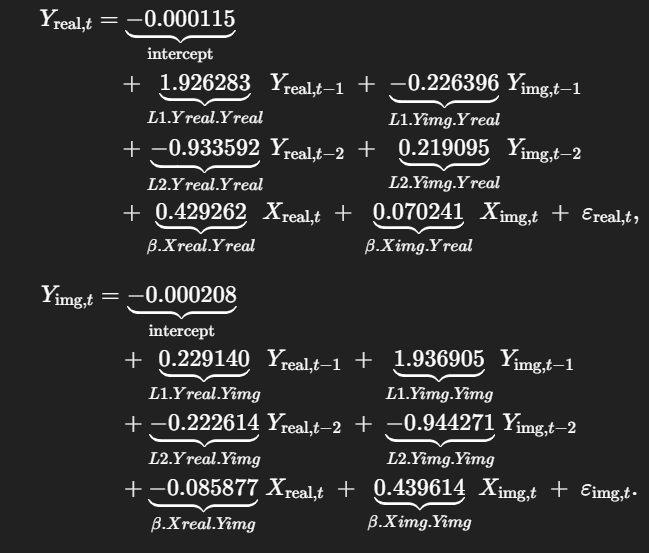

In [ ]:
params = final_res_lag_2.params.copy()
params.index = params.index.str.replace('.', ' → ', regex=False)  # formato mais visual
display(params.to_frame(name='Coeficiente'))

In [ ]:
df = final_res_lag_2.params.reset_index()
df.columns = ['param_name', 'value']

def parse_param(name):
    parts = name.split('.')
    if parts[0].startswith('L'):
        term, src, tgt = parts
    elif parts[0] == 'beta':
        term, src, tgt = parts
    elif parts[0] == 'intercept':
        term, src, tgt = parts[0], None, parts[1]
    elif parts[0] == 'sqrt' and len(parts) == 3:
        term, src, tgt = parts[0] + '.' + parts[1], None, parts[2]
    elif parts[0] == 'sqrt' and len(parts) == 4:
        term, src, tgt = parts[0] + '.' + parts[1], parts[2], parts[3]
    else:
        term, src, tgt = parts[0], None, None
    return term, src, tgt

df[['term', 'source', 'target']] = df['param_name'].apply(lambda x: pd.Series(parse_param(x)))

df = df[['term', 'source', 'target', 'value']]


In [ ]:
df.style.background_gradient(subset=['value'], cmap='coolwarm')

### Criação de um gráfico de resíduos para o conjunto de teste

In [ ]:
def grafico_residuos(Y_real, Y_pred, texto):
    # Cria o gráfico
    plt.figure(figsize=(15,15))
    plt.scatter(Y_real, Y_pred, color='blue', label='Predições', alpha=0.7)
    
    # Linha de referência (Y = Y_pred)
    min_val = min(Y_real.min(), Y_pred.min())
    max_val = max(Y_real.max(), Y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (Y=Ŷ)')
    
    # Rótulos e título
    plt.xlabel('Y real')
    plt.ylabel('Y predito')
    plt.title('Comparação entre Y real e Y predito ' + texto)
    plt.legend()
    plt.grid(True)
    plt.axis('equal')  # Escala 1:1
    plt.show()

In [ ]:
grafico_residuos(test['Yreal'], forecast_test_lag_2['Yreal'], "Para Lag == 2 e Y real")

In [ ]:
grafico_residuos(test['Yimg'], forecast_test_lag_2['Yimg'], "Para Lag == 2 e Y Imaginário")

#### Previsão com o modelo gerado de todos os dados (todas as amostras) para comparação com os valores de entrada

In [ ]:
endog_cols=('Yreal','Yimg')
exog_cols=('Xreal','Ximg')
endog_total = df_concat[list(endog_cols)]
exog_total = df_concat[list(exog_cols)]
forecast_todos_dados_lag_2 = final_res_lag_2.forecast(steps=len(endog_total), exog=exog_total)
forecast_todos_dados_lag_2.index = endog_total.index

In [ ]:
forecast_todos_dados_lag_2.tail()

In [ ]:
df_concat.tail()

In [ ]:
df_mag = pd.DataFrame()
df_mag["MAG_Input"] = np.sqrt(df_concat["Xreal"]**2 + df_concat["Ximg"]**2)
df_mag["MAG_Output_forecast"] = np.sqrt(forecast_todos_dados_lag_2["Yreal"]**2 + forecast_todos_dados_lag_2["Yimg"]**2)

df_mag["MAG_Input_Decibel"]= 20 * np.log10(df_mag["MAG_Input"])
df_mag["MAG_Output_Decibel_forecast"]= 20 * np.log10(df_mag["MAG_Output_forecast"])

df_mag["MAG_Input_Decibel"]= df_mag["MAG_Input_Decibel"]
df_mag["MAG_Output_Decibel_forecast"]= df_mag["MAG_Output_Decibel_forecast"]

plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel_forecast"], marker='o')
plt.xlabel('MAG_Input_Decibel')
plt.ylabel('MAG_Output_Decibel_forecast')
plt.title('Gráfico de y_forecast em função de X')
plt.show()

### Gerando simulação com as variáveis

### Criando um modelo invertido

In [ ]:
# 1) Selecionar lag
sel_inverted = select_lag_varx(train, val, endog_cols=('Xreal','Ximg'), exog_cols=('Yreal','Yimg'), max_lag=15)

# 2) Escolha automática pelo RMSE de validação
chosen_lag_inverted = sel_inverted['best_by_rmse']
print(f"\nUsando lag escolhido = {chosen_lag} (por RMSE de validação)")

In [ ]:
final_res_lag_12_inverted = fit_model_and_return(train_val, 12, endog_cols=('Xreal','Ximg'), exog_cols=('Yreal','Yimg'))
#final_res_lag_5_inverted, endog_cols_res_lag_5_inverted, endog_test_res_lag_5_inverted, forecast_test_lag_5_inverted, selected_lag_5_inverted = fit_and_plot_with_selected_lag(train_val, test, 5, endog_cols=('Xreal','Ximg'), exog_cols=('Yreal','Yimg'))

In [ ]:
final_res_lag_12_inverted, endog_test_res_lag_12_inverted, exog_test_res_lag_12_inverted, forecast_test_lag_12_inverted, selected_lag_12_inverted = testa_modelo(final_res_lag_12_inverted, test, endog_cols=('Xreal','Ximg'), exog_cols=('Yreal','Yimg'))

In [ ]:
final_res_lag_12_inverted_total = fit_model_and_return(df_concat, 12, endog_cols=('Xreal','Ximg'), exog_cols=('Yreal','Yimg'))

In [ ]:
final_res_lag_5_inverted_total = fit_model_and_return(df_concat, 5, endog_cols=('Xreal','Ximg'), exog_cols=('Yreal','Yimg'))

In [ ]:
final_res_lag_12_inverted.save("final_res_lag_12_inverted.pkl")

In [ ]:
final_res_lag_12_inverted_total.save("final_res_lag_12_inverted_total.pkl")

In [ ]:
graphModels(('Xreal','Ximg'), endog_test_res_lag_5_inverted, forecast_test_lag_5_inverted, selected_lag_5_inverted)

In [ ]:
grafico_residuos(test['Xreal'], forecast_test_lag_5_inverted['Xreal'], "Para Lag == 2 e Y real")

In [ ]:
grafico_residuos(test['Ximg'], forecast_test_lag_5_inverted['Ximg'], "Para Lag == 2 e Y real")

In [ ]:
endog_cols=('Yreal','Yimg')
exog_cols=('Xreal','Ximg')
endog_total = df_concat[list(endog_cols)]
exog_total = df_concat[list(exog_cols)]
forecast_todos_dados_lag_5_inverted = final_res_lag_5_inverted.forecast(steps=len(endog_total), exog=exog_total)
forecast_todos_dados_lag_5_inverted.index = endog_total.index

In [ ]:
forecast_todos_dados_lag_5_inverted

In [ ]:
df_mag = pd.DataFrame()
df_mag["MAG_Input"] = np.sqrt(df_concat["Xreal"]**2 + df_concat["Ximg"]**2)
df_mag["MAG_Output_forecast"] = np.sqrt(forecast_todos_dados_lag_5_inverted["Yreal"]**2 + forecast_todos_dados_lag_5_inverted["Yimg"]**2)

df_mag["MAG_Input_Decibel"]= 20 * np.log10(df_mag["MAG_Input"])
df_mag["MAG_Output_Decibel_forecast"]= 20 * np.log10(df_mag["MAG_Output_forecast"])

df_mag["MAG_Input_Decibel"]= df_mag["MAG_Input_Decibel"]
df_mag["MAG_Output_Decibel_forecast"]= df_mag["MAG_Output_Decibel_forecast"]

plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel_forecast"], marker='o')
plt.xlabel('MAG_Input_Decibel')
plt.ylabel('MAG_Output_Decibel_forecast')
plt.title('Gráfico de y_forecast em função de X')
plt.show()

### Predizendo o X com o modelo invertido

In [ ]:
final_res_lag_5, endog_cols_res_lag_5_inverted, endog_test_res_lag_5_inverted, forecast_test_lag_5_inverted, selected_lag_5_inverted = fit_and_plot_with_selected_lag(train_val, test, chosen_lag, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg'))

In [ ]:
# ======================================================
# 1️⃣ Tabela de Coeficientes (Convertida em Dicionário)
# ======================================================
data = [
    {"term": "intercept", "source": None, "target": "Yreal", "value": -0.000338},
    {"term": "intercept", "source": None, "target": "Yimg", "value": -0.000121},
    {"term": "L1", "source": "Yreal", "target": "Yreal", "value": 1.952430},
    {"term": "L1", "source": "Yimg", "target": "Yreal", "value": -0.240696},
    {"term": "L2", "source": "Yreal", "target": "Yreal", "value": -0.948212},
    {"term": "L2", "source": "Yimg", "target": "Yreal", "value": 0.237182},
    {"term": "L1", "source": "Yreal", "target": "Yimg", "value": 0.244416},
    {"term": "L1", "source": "Yimg", "target": "Yimg", "value": 1.956703},
    {"term": "L2", "source": "Yreal", "target": "Yimg", "value": -0.240537},
    {"term": "L2", "source": "Yimg", "target": "Yimg", "value": -0.952422},
    {"term": "beta", "source": "Xreal", "target": "Yreal", "value": 0.124069},
    {"term": "beta", "source": "Ximg", "target": "Yreal", "value": 0.001685},
    {"term": "beta", "source": "Xreal", "target": "Yimg", "value": -0.014196},
    {"term": "beta", "source": "Ximg", "target": "Yimg", "value": 0.127893}
]
df_model_lag_2 = pd.DataFrame(data)

In [ ]:
def calcula_modelo_PA_lag_2(df_model_lag_2):
# Variáveis na ordem: [Yreal, Yimg]
    A1 = np.zeros((2, 2))
    A2 = np.zeros((2, 2))
    B  = np.zeros((2, 2))
    c  = np.zeros(2)
    
    # Preenche A1, A2, B, c com base no DataFrame
    for _, row in df_model.iterrows():
        if row.term == 'L1':
            i = 0 if row.target == 'Yreal' else 1
            j = 0 if row.source == 'Yreal' else 1
            A1[i, j] = row.value
        elif row.term == 'L2':
            i = 0 if row.target == 'Yreal' else 1
            j = 0 if row.source == 'Yreal' else 1
            A2[i, j] = row.value
        elif row.term == 'beta':
            i = 0 if row.target == 'Yreal' else 1
            j = 0 if row.source == 'Xreal' else 1
            B[i, j] = row.value
        elif row.term == 'intercept':
            i = 0 if row.target == 'Yreal' else 1
            c[i] = row.value
    
    print("A1 =\n", A1)
    print("A2 =\n", A2)
    print("B  =\n", B)
    print("c  =\n", c)
    return A1, A2, B, c

In [ ]:
A1_lag_2, A2_lag_2, B_lag_2, C_lag_2 = calcula_modelo_PA_lag_2(df_model_lag_2)

In [ ]:
# ======================================================
# 2️⃣ Monta as matrizes A1, A2, B e o vetor c
# ======================================================
def simulacao(A1, A2, B, C, Xreal, Ximg):
    
    # ======================================================
    # 3️⃣ Simulação temporal
    # ======================================================
    n_steps = len(Xreal)
    Y = np.zeros((2, n_steps))
    X = np.zeros((2, n_steps))
    
    # Exemplo: entrada senoidal em Xreal e Ximg
    t = np.arange(n_steps)
    X[0, :] = Xreal
    X[1, :] = Ximg
    
    # Simulação discreta
    for k in range(2, n_steps):
        Y[:, k] = (
            A1 @ Y[:, k-1] +
            A2 @ Y[:, k-2] +
            B @ X[:, k] +
            C
        )
    
    # ======================================================
    # 4️⃣ Visualização
    # ======================================================
    plt.figure(figsize=(25, 17))
    plt.subplot(2,1,1)
    plt.plot(t, Y[0,:], label='Yreal')
    plt.plot(t, Y[1,:], label='Yimg')
    plt.title("Saídas do Modelo VARMAX (Simulação Discreta)")
    plt.legend(); plt.grid(True)
    
    plt.subplot(2,1,2)
    plt.plot(t, X[0,:], '--', label='Xreal (entrada)')
    plt.plot(t, X[1,:], '--', label='Ximg (entrada)')
    plt.legend(); plt.grid(True)
    
    plt.xlabel('Amostra (k)')
    plt.tight_layout()

    plt.show()
    return Y, X

In [ ]:
simulacao_lag_2_Y, simulacao_lag_2_X = simulacao(A1_lag_2, A2_lag_2, B_lag_2, C_lag_2, df_input["Xreal"], df_input["Ximg"])

In [ ]:
def gera_magnitude(Y, X):
    df_mag = pd.DataFrame()
    df_mag["MAG_Input"] = np.sqrt(X[0,:]**2 + X[1,:]**2)
    df_mag["MAG_Output_forecast_lag_2"] = np.sqrt(Y[0,:]**2 + Y[1,:]**2)
    
    df_mag["MAG_Input_Decibel"]= 20 * np.log10(df_mag["MAG_Input"])
    df_mag["MAG_Output_Decibel_forecast_lag_2"]= 20 * np.log10(df_mag["MAG_Output_forecast_lag_2"])
    
    df_mag["MAG_Input_Decibel"]= df_mag["MAG_Input_Decibel"]
    df_mag["MAG_Output_Decibel_forecast_lag_2"]= df_mag["MAG_Output_Decibel_forecast_lag_2"]
    
    plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel_forecast_lag_2"], marker='o')
    plt.xlabel('MAG_Input_Decibel')
    plt.ylabel('MAG_Output_Decibel_forecast')
    plt.title('Gráfico de y_forecast_lag_2 em função de X')

In [ ]:
gera_magnitude(simulacao_lag_2_Y, simulacao_lag_2_X)

### Modelo invertido: lag = 2

In [ ]:
# ======================================================
# Função que inverte o modelo (de Y para X)
# ======================================================
def inverter_modelo_PA_lag_2(A1_lag_2, A2_lag_2, B_lag_2, C_lag_2):
    # 2️⃣ Calcula inversa de B
    B_inv = np.linalg.inv(B_lag_2)

    # 3️⃣ Calcula coeficientes invertidos
    A1_inv = B_inv @ (-A1_lag_2)
    A2_inv = B_inv @ (-A2_lag_2)
    c_inv  = B_inv @ (-C_lag_2)

    # 4️⃣ Monta lista de dicionários no mesmo formato
    data_invertido = [
        # Interceptos
        {"term": "intercept", "source": None, "target": "Xreal", "value": float(c_inv[0])},
        {"term": "intercept", "source": None, "target": "Ximg",  "value": float(c_inv[1])},

        # L1 (Y_{t-1})
        {"term": "L1", "source": "Yreal", "target": "Xreal", "value": float(A1_inv[0, 0])},
        {"term": "L1", "source": "Yimg",  "target": "Xreal", "value": float(A1_inv[0, 1])},
        {"term": "L1", "source": "Yreal", "target": "Ximg",  "value": float(A1_inv[1, 0])},
        {"term": "L1", "source": "Yimg",  "target": "Ximg",  "value": float(A1_inv[1, 1])},

        # L2 (Y_{t-2})
        {"term": "L2", "source": "Yreal", "target": "Xreal", "value": float(A2_inv[0, 0])},
        {"term": "L2", "source": "Yimg",  "target": "Xreal", "value": float(A2_inv[0, 1])},
        {"term": "L2", "source": "Yreal", "target": "Ximg",  "value": float(A2_inv[1, 0])},
        {"term": "L2", "source": "Yimg",  "target": "Ximg",  "value": float(A2_inv[1, 1])},
    ]
    
    df_invertido = pd.DataFrame(data_invertido)
    return df_invertido, A1_inv, A2_inv, B_inv, c_inv

In [ ]:
df_invertido, A1_inv, A2_inv, B_inv, c_inv = inverter_modelo_PA_lag_2(A1_lag_2, A2_lag_2, B_lag_2, C_lag_2)

In [ ]:
simulacao_lag_2_inverted_Y, simulacao_lag_2_inverted_X = simulacao(A1_inv, A2_inv, B_inv, c_inv, df_input["Xreal"], df_input["Ximg"])

In [ ]:
gera_magnitude(simulacao_lag_2_inverted_Y, simulacao_lag_2_inverted_X)

In [ ]:
simulacao_lag_2_inverted_Y

### Métricas para performance do modelo para todos os dados

In [ ]:
simulacao_lag_2_Y_linear, simulacao_lag_2_X_pre_distorced = simulacao(A1, A2, B, c, simulacao_lag_2_inverted_Y[0,:], simulacao_lag_2_inverted_Y[1,:])

In [ ]:
gera_magnitude(simulacao_lag_2_Y_linear, simulacao_lag_2_X)

In [ ]:
# Cálculo das métricas por variável
for col in endog_cols:
    y_true = endog_total[col]
    y_pred = forecast_todos_dados_lag_2[col]
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - 2 - 1)
    std_err = np.std(y_true - y_pred)

    print(f"\nMétricas para {col} (teste, lag={2}):")
    print(f"  RMSE     = {rmse:.4f}")
    print(f"  MAE      = {mae:.4f}")
    print(f"  R²       = {r2:.4f}")
    print(f"  R² Ajust = {adj_r2:.4f}")
    print(f"  STD      = {std_err:.4f}")

### Criação de um modelo com lag == 10

In [ ]:
#Para Lag = 10
final_res_lag_10, forecast_teste_lag_10 = fit_and_plot_with_selected_lag(train_val, test, 10, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg'))

### Descrição do modelo (lag == 10)

In [ ]:
final_res_lag_10.params

In [ ]:
params = final_res_lag_10.params.copy()
params.index = params.index.str.replace('.', ' → ', regex=False)  # formato mais visual
display(params.to_frame(name='Coeficiente'))

In [ ]:
df = final_res_lag_10.params.reset_index()
df.columns = ['param_name', 'value']

def parse_param(name):
    parts = name.split('.')
    if parts[0].startswith('L'):
        term, src, tgt = parts
    elif parts[0] == 'beta':
        term, src, tgt = parts
    elif parts[0] == 'intercept':
        term, src, tgt = parts[0], None, parts[1]
    elif parts[0] == 'sqrt' and len(parts) == 3:
        term, src, tgt = parts[0] + '.' + parts[1], None, parts[2]
    elif parts[0] == 'sqrt' and len(parts) == 4:
        term, src, tgt = parts[0] + '.' + parts[1], parts[2], parts[3]
    else:
        term, src, tgt = parts[0], None, None
    return term, src, tgt

df[['term', 'source', 'target']] = df['param_name'].apply(lambda x: pd.Series(parse_param(x)))

df = df[['term', 'source', 'target', 'value']]


In [ ]:
df.style.background_gradient(subset=['value'], cmap='coolwarm')

### Gráfico de resíduos para o conjunto de teste com modelo de lag == 10

In [ ]:
grafico_residuos(test['Yreal'], forecast_teste_lag_10['Yreal'], "Para Lag == 10 e Y real")

In [ ]:
grafico_residuos(test['Yimg'], forecast_teste_lag_10['Yimg'], "Para Lag == 10 e Y Imaginario")

In [ ]:
endog_cols=('Yreal','Yimg')
exog_cols=('Xreal','Ximg')
endog_total = df_concat[list(endog_cols)]
exog_total = df_concat[list(exog_cols)]
forecast_lag_10 = final_res_lag_10.forecast(steps=len(endog_total), exog=exog_total)
forecast_lag_10.index = endog_total.index

In [ ]:
# Cálculo das métricas por variável
for col in endog_cols:
    y_true = endog_total[col]
    y_pred = forecast_lag_10[col]
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - 2 - 1)
    std_err = np.std(y_true - y_pred)

    print(f"\nMétricas para {col} (teste, lag={10}):")
    print(f"  RMSE     = {rmse:.4f}")
    print(f"  MAE      = {mae:.4f}")
    print(f"  R²       = {r2:.4f}")
    print(f"  R² Ajust = {adj_r2:.4f}")
    print(f"  STD      = {std_err:.4f}")

In [ ]:
df_mag = pd.DataFrame()
df_mag["MAG_Input"] = np.sqrt(df_concat["Xreal"]**2 + df_concat["Ximg"]**2)
df_mag["MAG_Output_forecast_lag_2"] = np.sqrt(forecast_lag_10["Yreal"]**2 + forecast_lag_10["Yimg"]**2)

df_mag["MAG_Input_Decibel"]= 20 * np.log10(df_mag["MAG_Input"])
df_mag["MAG_Output_Decibel_forecast_lag_2"]= 20 * np.log10(df_mag["MAG_Output_forecast_lag_2"])

df_mag["MAG_Input_Decibel"]= df_mag["MAG_Input_Decibel"]
df_mag["MAG_Output_Decibel_forecast_lag_2"]= df_mag["MAG_Output_Decibel_forecast_lag_2"]

plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel_forecast_lag_2"], marker='o')
plt.xlabel('MAG_Input_Decibel')
plt.ylabel('MAG_Output_Decibel_forecast')
plt.title('Gráfico de y_forecast_lag_2 em função de X')
plt.show()

In [ ]:
final_res_lag_20, forecast_teste_lag_20 = fit_and_plot_with_selected_lag(train_val, test, 15, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg'))

In [ ]:
final_res_lag_12, forecast_teste_lag_12 = fit_and_plot_with_selected_lag(train_val, test, 12, endog_cols=('Yreal','Yimg'), exog_cols=('Xreal','Ximg'))

### --- Criaando lags para variaveis exogenas manualmente

## Automação da Inserção de Lags nas Variáveis Exógenas

A função `build_exog_lags` gera automaticamente:
- Lags de ordem 1 até `max_lag_x` para cada coluna exógena
- (Opcional) Termos quadráticos de cada lag
- Remove NaNs e realinha os índices

In [ ]:
# ============================================================
# build_exog_lags: geração automática de lags exógenos
# ============================================================
def build_exog_lags(
    df,
    endog_cols=('Yreal', 'Yimg'),
    exog_base_cols=('Xreal', 'Ximg'),
    max_lag_x=2,
    include_quadratic=False,
    include_cross=False,
):
    """
    Cria DataFrame com variáveis endógenas + exógenas com lags automáticos.

    Parâmetros
    ----------
    df : DataFrame com colunas endog_cols e exog_base_cols
    endog_cols : tupla de colunas de saída (Y)
    exog_base_cols : tupla de colunas de entrada (X) base
    max_lag_x : número máximo de lags exógenos (1..max_lag_x)
    include_quadratic : se True, adiciona col^2 e col_lagK^2
    include_cross : se True, adiciona produto cruzado entre pares de exógenas

    Retorna
    -------
    df_out : DataFrame com endog + exog base + lags [+ quadráticos + cruzados]
    exog_all_cols : lista com todas as colunas exógenas geradas (para passar ao VARMAX)
    """
    df_out = pd.DataFrame(index=df.index)

    # Endógenas
    for c in endog_cols:
        df_out[c] = df[c]

    # Exógenas base (lag=0)
    for c in exog_base_cols:
        df_out[c] = df[c]

    exog_all_cols = list(exog_base_cols)

    # Lags 1..max_lag_x
    for lag in range(1, max_lag_x + 1):
        for c in exog_base_cols:
            col_name = f'{c}_lag{lag}'
            df_out[col_name] = df[c].shift(lag)
            exog_all_cols.append(col_name)

    # Termos quadráticos (base + lags)
    if include_quadratic:
        quad_targets = list(exog_base_cols)
        for lag in range(1, max_lag_x + 1):
            for c in exog_base_cols:
                quad_targets.append(f'{c}_lag{lag}')
        for col_name in quad_targets:
            sq_name = f'{col_name}_sq'
            df_out[sq_name] = df_out[col_name] ** 2
            exog_all_cols.append(sq_name)

    # Produtos cruzados entre pares de exógenas base
    if include_cross:
        cols = list(exog_base_cols)
        for i in range(len(cols)):
            for j in range(i + 1, len(cols)):
                cross_name = f'{cols[i]}_x_{cols[j]}'
                df_out[cross_name] = df_out[cols[i]] * df_out[cols[j]]
                exog_all_cols.append(cross_name)

    # Remove NaNs gerados pelos shifts
    df_out = df_out.dropna().reset_index(drop=True)

    return df_out, tuple(exog_all_cols)


### Gridsearch automático sobre o número de lags exógenos (`max_lag_x`)

Varre diferentes valores de `max_lag_x` e avalia o RMSE de validação para cada combinação com `p` (lag autoregressivo).

In [ ]:
# ============================================================
# select_lag_varx_with_exog_lags: gridsearch conjunto (p, max_lag_x)
# ============================================================
def select_lag_varx_with_exog_lags(
    df_full,
    endog_cols=('Yreal', 'Yimg'),
    exog_base_cols=('Xreal', 'Ximg'),
    max_ar_lag=5,
    max_exog_lag=4,
    train_frac=0.6,
    val_frac=0.2,
    include_quadratic=False,
    include_cross=False,
    verbose=True,
):
    """
    Gridsearch sobre (p=AR lag, max_lag_x=lags exógenos).
    Divide os dados internamente em treino/val com as frações fornecidas.

    Retorna DataFrame de resultados e melhor combinação por RMSE de validação.
    """
    from statsmodels.tsa.api import VARMAX
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    records = []

    for max_lag_x in range(0, max_exog_lag + 1):
        df_lagged, exog_all_cols = build_exog_lags(
            df_full,
            endog_cols=endog_cols,
            exog_base_cols=exog_base_cols,
            max_lag_x=max_lag_x,
            include_quadratic=include_quadratic,
            include_cross=include_cross,
        )

        # Re-divide após geração dos lags (NaNs já removidos)
        n = len(df_lagged)
        train_end = int(n * train_frac)
        val_end   = int(n * (train_frac + val_frac))

        train_l = df_lagged.iloc[:train_end]
        val_l   = df_lagged.iloc[train_end:val_end]

        for p in range(1, max_ar_lag + 1):
            try:
                model = VARMAX(
                    train_l[list(endog_cols)],
                    exog=train_l[list(exog_all_cols)],
                    order=(p, 0)
                )
                res = model.fit(disp=False, maxiter=200)

                fc = res.forecast(
                    steps=len(val_l),
                    exog=val_l[list(exog_all_cols)]
                )

                rmse_list, mae_list, r2_list = [], [], []
                for col in endog_cols:
                    yt = val_l[col].values
                    yp = fc[col].values
                    rmse_list.append(np.sqrt(mean_squared_error(yt, yp)))
                    mae_list.append(mean_absolute_error(yt, yp))
                    r2_list.append(r2_score(yt, yp))

                rec = {
                    'p': p,
                    'max_lag_x': max_lag_x,
                    'n_exog_cols': len(exog_all_cols),
                    'aic': res.aic,
                    'bic': res.bic,
                    'val_rmse_mean': np.mean(rmse_list),
                    'val_mae_mean':  np.mean(mae_list),
                    'val_r2_mean':   np.mean(r2_list),
                }
                records.append(rec)

                if verbose:
                    print(f"p={p:2d} | max_lag_x={max_lag_x} | n_exog={len(exog_all_cols):2d} "
                          f"| RMSE={np.mean(rmse_list):.5f} | R²={np.mean(r2_list):.4f} "
                          f"| AIC={res.aic:.1f}")

            except Exception as e:
                if verbose:
                    print(f"p={p:2d} | max_lag_x={max_lag_x} | ERRO: {e}")
                records.append({'p': p, 'max_lag_x': max_lag_x,
                                'val_rmse_mean': np.nan, 'aic': np.nan, 'bic': np.nan})

    results_df = pd.DataFrame(records)
    best_row = results_df.loc[results_df['val_rmse_mean'].idxmin()]

    if verbose:
        print("\n" + "="*60)
        print("MELHOR CONFIGURAÇÃO (por RMSE de validação):")
        print(best_row.to_string())
        print("="*60)

    return results_df, best_row


### Executando o Gridsearch (p, max_lag_x)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

results_grid, best_config = select_lag_varx_with_exog_lags(
    df_concat,
    endog_cols=('Yreal', 'Yimg'),
    exog_base_cols=('Xreal', 'Ximg'),
    max_ar_lag=5,       # testa p = 1..5
    max_exog_lag=4,     # testa max_lag_x = 0..4
    train_frac=0.6,
    val_frac=0.2,
    include_quadratic=False,  # altere para True para testar termos quadráticos
    include_cross=False,
    verbose=True,
)


### Visualização dos resultados do Gridsearch

In [ ]:
import seaborn as sns

# Pivot table: RMSE médio (val) por (p, max_lag_x)
pivot_rmse = results_grid.pivot_table(
    index='p', columns='max_lag_x', values='val_rmse_mean'
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_rmse, annot=True, fmt='.5f', cmap='YlOrRd_r',
            linewidths=0.5, cbar_kws={'label': 'RMSE Validação'})
plt.title('Gridsearch: RMSE de Validação por (p=AR lag, max_lag_x=lags exógenos)')
plt.xlabel('max_lag_x (lags exógenos)')
plt.ylabel('p (lag autoregressivo)')
plt.tight_layout()
plt.show()

print(f"\nMelhor: p={int(best_config['p'])}, max_lag_x={int(best_config['max_lag_x'])}, "
      f"RMSE={best_config['val_rmse_mean']:.5f}")


### Treinando o modelo final com a melhor configuração encontrada

In [ ]:
# ── Usa os valores do gridsearch automaticamente ──────────────────────────────
best_p        = int(best_config['p'])
best_lag_x    = int(best_config['max_lag_x'])

# Reconstrói o DataFrame com lags da configuração ótima
df_best, exog_best_cols = build_exog_lags(
    df_concat,
    endog_cols=('Yreal', 'Yimg'),
    exog_base_cols=('Xreal', 'Ximg'),
    max_lag_x=best_lag_x,
    include_quadratic=False,
    include_cross=False,
)

# Divisão treino / val / test
n = len(df_best)
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

train_best     = df_best.iloc[:train_end]
val_best       = df_best.iloc[train_end:val_end]
test_best      = df_best.iloc[val_end:]
train_val_best = pd.concat([train_best, val_best], ignore_index=True)

print(f"Configuração escolhida: p={best_p}, max_lag_x={best_lag_x}")
print(f"Colunas exógenas ({len(exog_best_cols)}): {exog_best_cols}")
print(f"Tamanhos — treino+val: {len(train_val_best)} | teste: {len(test_best)}")


In [ ]:
# Treina modelo final (treino+val) com a melhor configuração
final_model_auto = fit_model_and_return(
    train_val_best,
    selected_lag=best_p,
    endog_cols=('Yreal', 'Yimg'),
    exog_cols=exog_best_cols,
)

# Avalia no conjunto de teste
final_model_auto, endog_test_auto, exog_test_auto, forecast_test_auto, _ = testa_modelo(
    best_p, final_model_auto, test_best,
    endog_cols=('Yreal', 'Yimg'),
    exog_cols=exog_best_cols,
)


### Gráfico de resíduos — modelo automatizado

In [ ]:
grafico_residuos(test_best['Yreal'], forecast_test_auto['Yreal'],
                 f"Modelo Auto | p={best_p}, max_lag_x={best_lag_x} | Yreal")
grafico_residuos(test_best['Yimg'],  forecast_test_auto['Yimg'],
                 f"Modelo Auto | p={best_p}, max_lag_x={best_lag_x} | Yimg")


### Previsão em todo o dataset com o modelo final

In [ ]:
forecast_full_auto = final_model_auto.forecast(
    steps=len(df_best),
    exog=df_best[list(exog_best_cols)]
)
forecast_full_auto.index = df_best.index

# Gráfico magnitude
df_mag_auto = pd.DataFrame()
df_mag_auto['MAG_Input']   = np.sqrt(df_best['Xreal']**2 + df_best['Ximg']**2)
df_mag_auto['MAG_Output']  = np.sqrt(forecast_full_auto['Yreal']**2 + forecast_full_auto['Yimg']**2)
df_mag_auto['MAG_In_dB']   = 20 * np.log10(df_mag_auto['MAG_Input'])
df_mag_auto['MAG_Out_dB']  = 20 * np.log10(df_mag_auto['MAG_Output'])

plt.figure(figsize=(12, 5))
plt.plot(df_mag_auto['MAG_In_dB'], df_mag_auto['MAG_Out_dB'], marker='o', markersize=3)
plt.xlabel('MAG_Input (dB)')
plt.ylabel('MAG_Output (dB)')
plt.title(f'Saída prevista vs Entrada — Modelo Auto (p={best_p}, max_lag_x={best_lag_x})')
plt.grid(True)
plt.tight_layout()
plt.show()
